<a href="https://colab.research.google.com/github/sebastianquintanam/dataexperience-final-project/blob/main/notebooks/Etapa2_Analisis_Estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final DataXperience
## Etapa 2: Análisis estadístico

**Hecho por:** Jhonatan Stiben Rey Velasquez

Acá trabajamos con el archivo que salió de la Etapa 1. La idea es entender cómo se
comportan los datos antes de meterles cualquier modelo: qué valores son típicos, qué
tanto varían, qué forma tienen las distribuciones, si hay valores raros y qué variables
parecen tener relación con el precio.

## 2.1 Cargamos el archivo limpio

Ojo que acá no usamos el CSV original sino el que dejó lista la Etapa 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('laptop_price_limpio.csv')

print("Dimensiones:", df.shape)
print("Nulos:", df.isnull().sum().sum())
df.head()

Dimensiones: (1303, 18)
Nulos: 0


,Company,TypeName,Inches,Ram_GB,Weight_kg,Touchscreen,IPS,Res_X,Res_Y,PPI,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Cpu_gama,Gpu_marca,SO,Price_euros
0,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,128.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1339.69
1,Apple,Ultrabook,13.3,8,1.34,0,0,1440,900,127.677940,0.0,0.0,128.0,0.0,Intel Core i5,Intel,Mac,898.94
2,HP,Notebook,15.6,8,1.86,0,0,1920,1080,141.211998,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Otro,575.00
3,Apple,Ultrabook,15.4,16,1.83,0,1,2880,1800,220.534624,512.0,0.0,0.0,0.0,Intel Core i7,AMD,Mac,2537.45
4,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1803.60


In [2]:
# separamos las numéricas que vamos a analizar
numericas = ['Price_euros', 'Ram_GB', 'Weight_kg', 'Inches', 'PPI', 'SSD_GB', 'HDD_GB']
df[numericas].head()

,Price_euros,Ram_GB,Weight_kg,Inches,PPI,SSD_GB,HDD_GB
0,1339.69,8,1.37,13.3,226.983005,128.0,0.0
1,898.94,8,1.34,13.3,127.677940,0.0,0.0
2,575.00,8,1.86,15.6,141.211998,256.0,0.0
3,2537.45,16,1.83,15.4,220.534624,512.0,0.0
4,1803.60,8,1.37,13.3,226.983005,256.0,0.0


## 2.2 Medidas de tendencia central

Calculamos media, mediana y moda para cada variable numérica. Comparar las tres sirve
para darse una idea de si la distribución está balanceada o no: cuando la media se aleja
mucho de la mediana es porque hay valores extremos jalando el promedio.

In [3]:
tendencia = pd.DataFrame({
    'Media': df[numericas].mean(),
    'Mediana': df[numericas].median(),
    'Moda': df[numericas].mode().iloc[0]
})

# diferencia porcentual entre media y mediana
# (si la mediana es 0 no se puede calcular, lo dejamos vacío)
tendencia['Dif. media-mediana (%)'] = np.where(
    tendencia['Mediana'] != 0,
    (tendencia['Media'] - tendencia['Mediana']) / tendencia['Mediana'] * 100,
    np.nan)

print(tendencia.round(2))

               Media  Mediana     Moda  Dif. media-mediana (%)
Price_euros  1123.69   977.00  1099.00                   15.01
Ram_GB          8.38     8.00     8.00                    4.78
Weight_kg       2.04     2.04     2.20                   -0.06
Inches         15.02    15.60    15.60                   -3.74
PPI           146.64   141.21   141.21                    3.84
SSD_GB        183.73   256.00   256.00                  -28.23
HDD_GB        413.78     0.00     0.00                     NaN


### Qué nos dice esto

En el precio la media queda en unos 1.124 euros pero la mediana en 977. O sea que el
promedio está por encima de lo que realmente paga la mayoría, porque hay unos portátiles
muy caros que lo jalan hacia arriba. **Para hablar del precio típico es mejor usar la
mediana.**

El caso más llamativo es `HDD_GB`: la media da 414 GB pero la mediana da 0. Eso pasa
porque más de la mitad de los equipos no traen disco duro mecánico, solo SSD. Cuando la
mayoría de los valores son cero, el promedio deja de significar algo útil.

En `Inches` y `Weight_kg` en cambio la media y la mediana son casi iguales, así que esas
sí están repartidas de forma más pareja.

## 2.3 Medidas de dispersión

Ahora miramos qué tanto se separan los datos. Además del rango, la varianza y la
desviación estándar, agregamos el **coeficiente de variación**, que es la desviación
dividida entre la media. Sirve para comparar variables que están en unidades distintas:
no se puede comparar directo una desviación en euros contra una en kilos.

In [4]:
dispersion = pd.DataFrame({
    'Mínimo': df[numericas].min(),
    'Máximo': df[numericas].max(),
    'Rango': df[numericas].max() - df[numericas].min(),
    'Varianza': df[numericas].var(),
    'Desv. estándar': df[numericas].std()
})

dispersion['Coef. variación'] = df[numericas].std() / df[numericas].mean()

print(dispersion.round(2))

             Mínimo   Máximo    Rango   Varianza  Desv. estándar  \
Price_euros  174.00  6099.00  5925.00  488613.64          699.01   
Ram_GB         2.00    64.00    62.00      25.85            5.08   
Weight_kg      0.69     4.70     4.01       0.44            0.67   
Inches        10.10    18.40     8.30       2.03            1.43   
PPI           90.58   352.47   261.88    1859.45           43.12   
SSD_GB         0.00  1024.00  1024.00   34956.62          186.97   
HDD_GB         0.00  2000.00  2000.00  266069.01          515.82   

             Coef. variación  
Price_euros             0.62  
Ram_GB                  0.61  
Weight_kg               0.33  
Inches                  0.09  
PPI                     0.29  
SSD_GB                  1.02  
HDD_GB                  1.25  


### Qué nos dice esto

El coeficiente de variación deja ver cuáles variables son más dispersas en términos
relativos. `HDD_GB` y `SSD_GB` son las más variables (más de 1), que tiene sentido porque
hay equipos sin ninguno de los dos y otros con 1 o 2 TB.

En el otro extremo, `Inches` tiene un coeficiente de apenas 0.09: casi todos los
portátiles miden entre 14 y 15.6 pulgadas. Es una variable bastante uniforme, lo cual
adelanta algo — si casi no varía, difícilmente va a servir para explicar diferencias
de precio.

## 2.4 Forma de las distribuciones

La asimetría (skewness) dice hacia dónde está estirada la distribución y la curtosis
qué tan pesadas son las colas.

Para leerlas:
- Asimetría cerca de 0 es simétrica; positiva es estirada a la derecha; negativa a la izquierda
- Curtosis alta significa que hay más valores extremos de lo normal

In [5]:
forma = pd.DataFrame({
    'Asimetría': df[numericas].skew(),
    'Curtosis': df[numericas].kurtosis()
})

def interpretar(s):
    if s > 1: return 'Muy sesgada a la derecha'
    elif s > 0.5: return 'Sesgada a la derecha'
    elif s > -0.5: return 'Aproximadamente simétrica'
    elif s > -1: return 'Sesgada a la izquierda'
    else: return 'Muy sesgada a la izquierda'

forma['Interpretación'] = forma['Asimetría'].apply(interpretar)
print(forma.round(2))

             Asimetría  Curtosis             Interpretación
Price_euros       1.52      4.37   Muy sesgada a la derecha
Ram_GB            2.69     15.34   Muy sesgada a la derecha
Weight_kg         1.14      2.46   Muy sesgada a la derecha
Inches           -0.45     -0.07  Aproximadamente simétrica
PPI               2.02      5.08   Muy sesgada a la derecha
SSD_GB            1.37      3.22   Muy sesgada a la derecha
HDD_GB            0.89     -0.04       Sesgada a la derecha


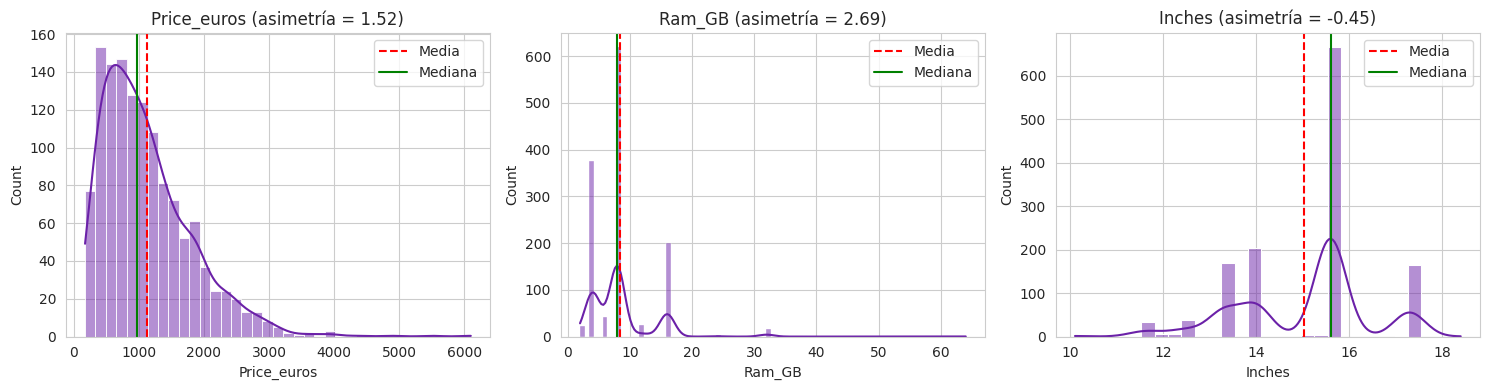

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Price_euros', 'Ram_GB', 'Inches']):
    sns.histplot(df[col], kde=True, ax=ax, color='#6B21A8')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df[col].median(), color='green', linestyle='-', label='Mediana')
    ax.set_title(f'{col} (asimetría = {df[col].skew():.2f})')
    ax.legend()

plt.tight_layout()
plt.show()

### Qué nos dice esto

Casi todas las variables están sesgadas a la derecha. El precio tiene asimetría de 1.52
y la RAM de 2.69, que es bastante alta. En los gráficos se ve clarito: la línea roja
(media) queda a la derecha de la verde (mediana) en el precio y en la RAM, mientras que
en las pulgadas están casi encima una de otra.

`Inches` es la única con asimetría negativa (-0.45), o sea ligeramente estirada hacia
la izquierda, aunque bastante cerca de ser simétrica.

La RAM también tiene una curtosis de 15.3, que es altísima. Eso significa que hay muchos
valores concentrados en el centro (casi todos los equipos son de 4 u 8 GB) y unos pocos
muy alejados (los de 32 y 64 GB).

## 2.5 Detección de valores atípicos

Para encontrar los outliers usamos el método del rango intercuartílico. La idea es
calcular el primer y el tercer cuartil, sacar la diferencia (el IQR), y considerar
atípico todo lo que quede más allá de 1.5 veces el IQR por debajo de Q1 o por encima
de Q3.

Es el mismo criterio que usan los diagramas de caja para dibujar los bigotes.

In [7]:
def detectar_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    atipicos = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Límite inf.': limite_inf, 'Límite sup.': limite_sup,
        'N° atípicos': atipicos,
        '% del total': atipicos / len(serie) * 100
    })

outliers = df[numericas].apply(detectar_outliers).T
print(outliers.round(2))

                 Q1       Q3      IQR  Límite inf.  Límite sup.  N° atípicos  \
Price_euros  599.00  1487.88   888.88      -734.32      2821.20         29.0   
Ram_GB         4.00     8.00     4.00        -2.00        14.00        221.0   
Weight_kg      1.50     2.30     0.80         0.30         3.50         46.0   
Inches        14.00    15.60     1.60        11.60        18.00         39.0   
PPI          127.34   157.35    30.01        82.31       202.37        116.0   
SSD_GB         0.00   256.00   256.00      -384.00       640.00         18.0   
HDD_GB         0.00  1000.00  1000.00     -1500.00      2500.00          0.0   

             % del total  
Price_euros         2.23  
Ram_GB             16.96  
Weight_kg           3.53  
Inches              2.99  
PPI                 8.90  
SSD_GB              1.38  
HDD_GB              0.00  


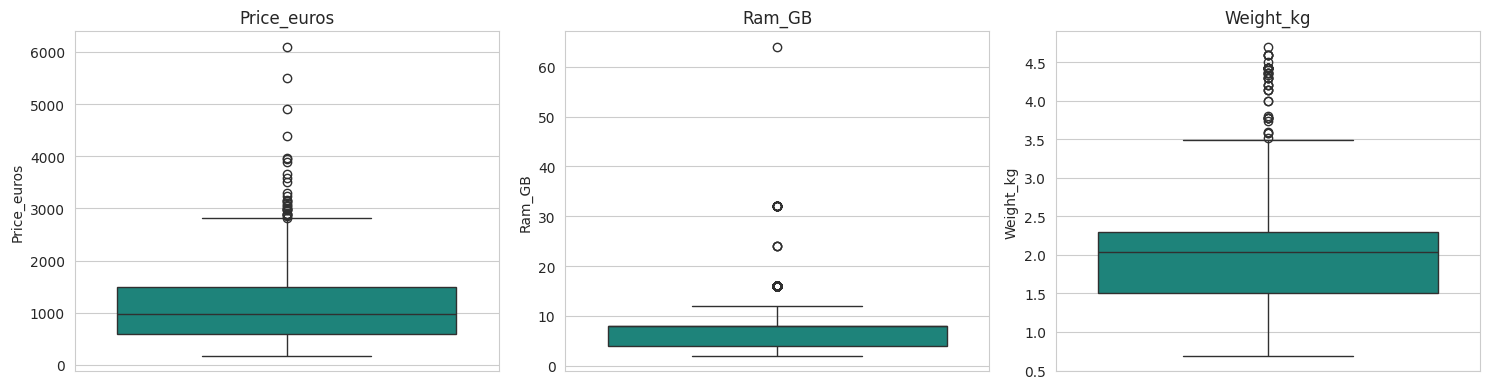

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Price_euros', 'Ram_GB', 'Weight_kg']):
    sns.boxplot(y=df[col], ax=ax, color='#0D9488')
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()

In [9]:
# miramos qué equipos son los que el método marca como atípicos en RAM
atipicos_ram = df[df['Ram_GB'] > outliers.loc['Ram_GB', 'Límite sup.']]

print("Equipos marcados como atípicos por RAM:", len(atipicos_ram))
print("\nCómo se reparten por tipo de equipo:")
print(atipicos_ram['TypeName'].value_counts())
print("\nRAM de esos equipos:")
print(atipicos_ram['Ram_GB'].value_counts().sort_index())

Equipos marcados como atípicos por RAM: 221

Cómo se reparten por tipo de equipo:
TypeName
Gaming                116
Ultrabook              38
Notebook               34
2 in 1 Convertible     23
Workstation             9
Netbook                 1
Name: count, dtype: int64

RAM de esos equipos:
Ram_GB
16    200
24      3
32     17
64      1
Name: count, dtype: int64


### Qué nos dice esto

Acá aparece algo que vale la pena aclarar. El método marca **221 equipos como atípicos
por RAM**, que es el 17% del dataset. Es un montón.

Pero al revisar cuáles son, resulta que son equipos de 12, 16, 24, 32 y 64 GB, y en su
mayoría son Gaming y Workstation. **No son errores, son equipos de gama alta reales.**

Lo que pasa es que como la gran mayoría del catálogo son portátiles de 4 y 8 GB, el
rango intercuartílico queda muy angosto (Q1=4, Q3=8, IQR=4) y cualquier cosa por encima
de 14 GB cae fuera del límite. El método está funcionando bien, pero un valor atípico
en el sentido estadístico no siempre es un dato malo.

**Por eso no los eliminamos.** Si los quitáramos estaríamos borrando justo los equipos
más potentes, que son los que explican los precios altos. Los dejamos y lo dejamos
anotado, que es distinto a ignorarlos.

En el precio en cambio los atípicos son solo 29 (2.2%) y corresponden a portátiles de
más de 2.800 euros, que también son reales.

## 2.6 Comparación entre variables

Ahora miramos qué relación tiene cada variable con el precio, que es lo que al final
queremos entender.

Empezamos con las numéricas usando correlación.

In [10]:
correlaciones = df[numericas].corr()['Price_euros'].drop('Price_euros')
correlaciones = correlaciones.sort_values(ascending=False)

print("Correlación de cada variable con el precio:")
print(correlaciones.round(3))

Correlación de cada variable con el precio:
Ram_GB       0.743
SSD_GB       0.671
PPI          0.473
Weight_kg    0.210
Inches       0.068
HDD_GB      -0.096
Name: Price_euros, dtype: float64


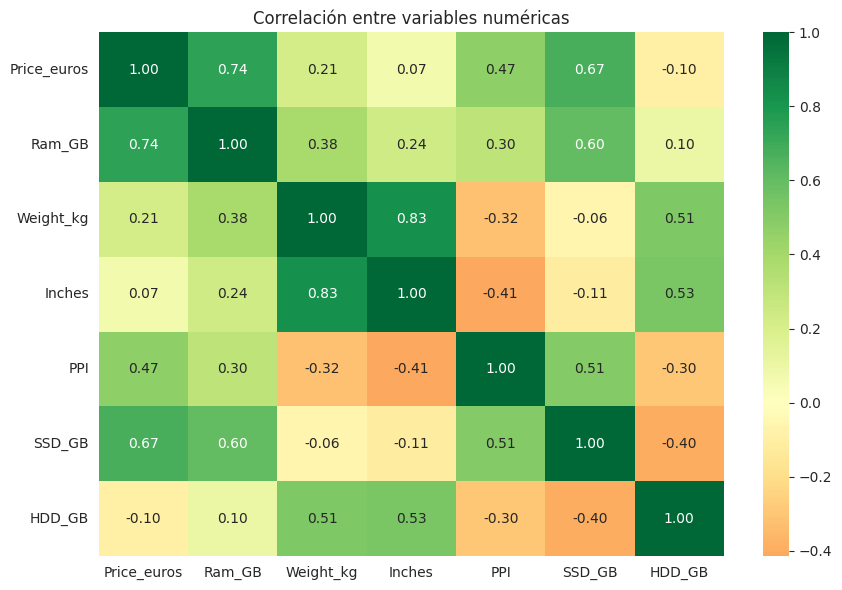

In [11]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

### Qué nos dice esto

La RAM es la que más se relaciona con el precio (0.74), seguida del SSD (0.67) y del
PPI (0.47). Tiene sentido: más memoria, más disco sólido y mejor pantalla salen más caro.

Dos cosas curiosas:

**Las pulgadas casi no se relacionan con el precio** (0.07). Uno pensaría que un portátil
más grande cuesta más, pero no: hay equipos de 15.6 pulgadas baratísimos y ultrabooks de
13 pulgadas carísimos. El tamaño solo no dice nada de la gama.

**El disco duro tiene correlación negativa** (-0.10). O sea que a más disco duro, un poco
menos de precio. Suena raro pero se explica: los equipos con HDD son en general los de
gama baja, mientras que los caros vienen con SSD. No es que el disco duro abarate el
equipo, es que va de la mano con equipos económicos.

Ahora comparamos el precio entre las variables categóricas.

In [12]:
for columna in ['TypeName', 'SO', 'Cpu_gama', 'Gpu_marca']:
    resumen = df.groupby(columna)['Price_euros'].agg(['count', 'mean', 'median', 'std'])
    resumen = resumen.sort_values('median', ascending=False)
    print(f"--- Precio según {columna} ---")
    print(resumen.round(0))
    print()

--- Precio según TypeName ---
                    count    mean  median    std
TypeName                                        
Workstation            29  2280.0  2065.0  713.0
Ultrabook             196  1548.0  1499.0  489.0
Gaming                205  1731.0  1493.0  814.0
2 in 1 Convertible    121  1282.0  1199.0  613.0
Notebook              727   782.0   691.0  444.0
Netbook                25   636.0   340.0  581.0

--- Precio según SO ---
         count    mean  median    std
SO                                   
Mac         21  1564.0  1340.0  562.0
Windows   1125  1190.0  1049.0  707.0
Linux       62   617.0   579.0  253.0
Otro        95   575.0   479.0  339.0

--- Precio según Cpu_gama ---
                    count    mean  median    std
Cpu_gama                                        
Intel Core i7         527  1596.0  1476.0  704.0
Intel Core M           19  1324.0  1262.0  612.0
Intel Core i5         423  1015.0   955.0  376.0
Intel Core i3         136   542.0   499.0  143.0


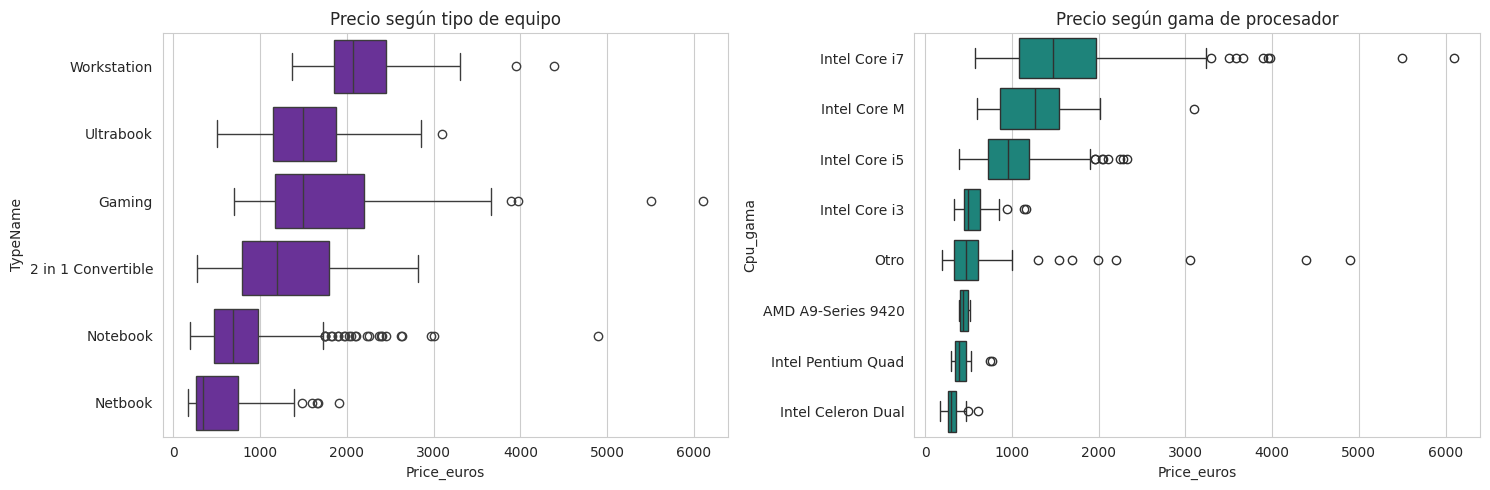

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden_tipo = df.groupby('TypeName')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='TypeName', data=df, order=orden_tipo, ax=axes[0], color='#6B21A8')
axes[0].set_title('Precio según tipo de equipo')

orden_cpu = df.groupby('Cpu_gama')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='Cpu_gama', data=df, order=orden_cpu, ax=axes[1], color='#0D9488')
axes[1].set_title('Precio según gama de procesador')

plt.tight_layout()
plt.show()

In [14]:
# las dos variables binarias
for columna in ['Touchscreen', 'IPS']:
    resumen = df.groupby(columna)['Price_euros'].agg(['count', 'mean', 'median'])
    diferencia = resumen.loc[1, 'median'] - resumen.loc[0, 'median']
    print(f"--- {columna} ---")
    print(resumen.round(0))
    print(f"Diferencia en la mediana: {diferencia:.0f} euros")
    print()

--- Touchscreen ---
             count    mean  median
Touchscreen                       
0             1111  1068.0   919.0
1              192  1445.0  1399.0
Diferencia en la mediana: 480 euros

--- IPS ---
     count    mean  median
IPS                       
0      938  1014.0   848.0
1      365  1406.0  1260.0
Diferencia en la mediana: 412 euros



### Qué nos dice esto

**Por tipo de equipo** hay diferencias grandes. Las Workstation tienen una mediana de
2.065 euros y los Netbook de 340. Los Notebook, que son la mayoría del catálogo (727 de
1.303), están en 691, o sea que son la gama de entrada.

**Por procesador** el orden es el que uno esperaría: i7 arriba (mediana 1.476), después
i5 (955), i3 (499) y los Celeron abajo (298). La progresión es bien clara.

**Por sistema operativo** los Mac son los más caros, pero hay que tener cuidado con esa
conclusión: son solo 21 equipos de 1.303. Con tan pocos casos el dato no es muy confiable.
Los Windows, con 1.125 equipos, sí son representativos.

**Las binarias** también muestran diferencia. Los equipos con pantalla táctil tienen una
mediana 480 euros más alta, y los que tienen panel IPS 412 euros más. Aunque acá vale
la pena aclarar que probablemente no es la pantalla en sí la que sube el precio, sino
que ese tipo de pantallas vienen en equipos de gama alta que ya son caros por otras
razones.

## 2.7 Hipótesis para la siguiente etapa

De todo lo anterior salen algunas ideas que la Etapa 3 puede probar con el modelo:

1. **La RAM y el SSD son los que más pesan en el precio.** Son las dos correlaciones más
   altas (0.74 y 0.67), así que deberían ser las variables más importantes del modelo.

2. **El tamaño de pantalla no sirve para predecir el precio,** pero el PPI sí (0.47).
   Lo que importa no es qué tan grande es la pantalla sino qué tan buena.

3. **El tipo de equipo y la gama del procesador son buenos separadores.** Las medianas
   entre categorías son muy distintas, o sea que agrupan bien.

4. **Cuidado con el disco duro.** Su correlación negativa no significa que abarate el
   equipo, sino que viene en equipos de gama baja. Meterlo al modelo sin entender esto
   puede llevar a interpretaciones equivocadas.

5. **La distribución del precio está sesgada.** Eso puede afectar a un modelo de regresión
   lineal, que asume cierta simetría en los errores. Podría valer la pena revisarlo.

## Resumen de la Etapa 2

Lo que hicimos:

- Calculamos media, mediana y moda, y vimos que en el precio la mediana representa
  mejor el valor típico porque la distribución está sesgada
- Medimos la dispersión con rango, varianza, desviación estándar y coeficiente de
  variación, que permite comparar variables con unidades distintas
- Analizamos la forma con asimetría y curtosis: casi todas las variables están
  estiradas hacia la derecha
- Detectamos outliers con el método del rango intercuartílico y decidimos conservarlos
  después de revisar que son equipos de gama alta reales, no errores
- Comparamos el precio contra todas las variables, numéricas y categóricas, y dejamos
  cinco hipótesis planteadas para el modelo